# Experimental Plan

We evaluate **EQRM** against **ERM**, **IRM**, **VREx**, and a shape-only **Oracle** across a battery of spurious-correlation benchmarks. Our goal is to identify *when* EQRM's quantile-risk objective provides an advantage over peers, and *what* structural properties of training data drive OOD generalization.

## Research Questions

1. **When does EQRM work?** Under what training regimes, on what kinds of problems, and against what kinds of spurious features?
2. **How does EQRM compare to invariance peers (IRM, VREx)?** Does it differentiate itself beyond the canonical CMNIST setup in the original paper?
3. **What drives generalization — domain count or domain diversity?** Does the theorem's $m \to \infty$ guarantee translate into an actionable lever for practitioners?

## Experiments

| # | Experiment | Purpose |
|---|------------|---------|
| 1 | **Binary CMNIST — Reproduce** | Validate pipeline; establish baseline (color = linear shortcut) |
| 2 | **Spurious Strength Ablation** | Identify the regime where EQRM actually matters (spurious vs. causal feature competition) |
| 3 | **Burn-in Ablation** | Test whether EQRM requires ERM pretraining or works standalone |
| 4 | **MC-CMNIST** | Scale to 10 classes × 10 colors — compositional spurious structure |
| 5 | **BIM-CMNIST** | Non-linear interleaved color pools — test unlearning of complex shortcuts |
| 6 | **CFMNIST** | Fashion items (harder invariant features) with simple color shortcut |
| 7 | **RMNIST** | New benchmark: continuous rotation parameter, no label noise, $\delta=0$ probe |
| 8 | **RMNIST — N × Spread Grid** | Decouple *number* of domains from *diversity* of domains |

## Expected Contribution

Beyond reproducing the paper's canonical CMNIST result, this evaluation tests whether EQRM's advantages generalize across task structures and spurious-feature geometries, and whether the paper's emphasis on domain count reflects the true driver of OOD performance.

Install dependencies

In [1]:
import sys
import os
import shutil
from google.colab import drive

# Mount Google Drive (for reading code + saving results)
drive.mount('/content/drive')

# Source on Drive, destination on local Colab disk
DRIVE_ROOT = '/content/drive/MyDrive/IFT6168/qrm/CMNIST/'
LOCAL_ROOT = '/content/CMNIST/'

# Copy files to local Colab disk for faster execution (Fixed)
if os.path.exists(LOCAL_ROOT):
    shutil.rmtree(LOCAL_ROOT) # Clean up if it already exists from a previous run
shutil.copytree(DRIVE_ROOT, LOCAL_ROOT)

# Work from the LOCAL copy
PROJECT_ROOT = LOCAL_ROOT
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

%cd {PROJECT_ROOT}

# Install dependencies (Fixed path)
!pip install -q -r requirements.txt

# Setup Results directories on Drive
RESULTS_DIR = '/content/drive/MyDrive/IFT6168/qrm/CMNIST/results/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'plots'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'raw'), exist_ok=True)

print(f"Code dir (fast):    {os.getcwd()}")
print(f"Results dir (Drive): {RESULTS_DIR}")

Mounted at /content/drive
/content/CMNIST
Code dir (fast):    /content/CMNIST
Results dir (Drive): /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/


Environment & file check

In [2]:
import torch, glob

# GPU
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU detected — training will be very slow")

# Verify all required files were copied from Drive
required = [
    # Binary CMNIST
    'train.py', 'datasets.py',
    # MC-CMNIST
    'train_mc.py', 'datasets_mc.py',
    # BIM
    'train_bim.py', 'datasets_bim.py',
    # CFashionMNIST
    'train_cfmnist.py', 'datasets_cfmnist.py',
    # RMNIST
    'train_rmnist.py', 'datasets_rmnist.py',
    # Shared infrastructure
    'algorithms.py', 'networks.py',
    'run_experiments.py', 'plot_results.py',
    'collect_results.py',
    # Job script generators
    'job_scripts/gen_exps_ndomain.py',
    'job_scripts/gen_exps_burnin.py',
    'job_scripts/gen_exps_spurious.py',
    'job_scripts/gen_exps_mc.py',
    'job_scripts/gen_exps_bim.py',
    'job_scripts/gen_exps_cfmnist.py',
    'job_scripts/gen_exps_rmnist.py',
    'job_scripts/gen_exps_rmnist_grid.py',
    # Lib
    'lib/misc.py', 'lib/fast_data_loader.py',
]

all_ok = True
for f in required:
    ok = os.path.exists(f)
    all_ok = all_ok and ok
    print(f"  {'OK  ' if ok else 'MISS'} {f}")

if not all_ok:
    raise FileNotFoundError("Some files are missing — re-run Cell 1 to re-copy from Drive")
print("\nAll files present.")

  OK   train.py
  OK   datasets.py
  OK   train_mc.py
  OK   datasets_mc.py
  OK   train_bim.py
  OK   datasets_bim.py
  OK   train_cfmnist.py
  OK   datasets_cfmnist.py
  OK   train_rmnist.py
  OK   datasets_rmnist.py
  OK   algorithms.py
  OK   networks.py
  OK   run_experiments.py
  OK   plot_results.py
  OK   collect_results.py
  OK   job_scripts/gen_exps_ndomain.py
  OK   job_scripts/gen_exps_burnin.py
  OK   job_scripts/gen_exps_spurious.py
  OK   job_scripts/gen_exps_mc.py
  OK   job_scripts/gen_exps_bim.py
  OK   job_scripts/gen_exps_cfmnist.py
  OK   job_scripts/gen_exps_rmnist.py
  OK   job_scripts/gen_exps_rmnist_grid.py
  OK   lib/misc.py
  OK   lib/fast_data_loader.py

All files present.


Paths, data download, generate command files

In [3]:
# ------------------------------------------------------------------
# Path config
# ------------------------------------------------------------------
DATA_DIR    = '/content/data/'                          # local — MNIST download (fast)
OUTPUT_DIR  = DRIVE_ROOT                                # Drive root — results persist across reconnects
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'results', 'figures')

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"DATA_DIR    : {DATA_DIR}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"FIGURES_DIR : {FIGURES_DIR}")

# ------------------------------------------------------------------
# Pre-download MNIST once so all runs can start immediately
# ------------------------------------------------------------------
from torchvision.datasets import MNIST
MNIST(DATA_DIR, train=True,  download=True)
MNIST(DATA_DIR, train=False, download=True)
print("MNIST ready.")

# ------------------------------------------------------------------
# Generate all command files (binary + MC) - CHANGE TO 3
# ------------------------------------------------------------------
!python run_experiments.py generate \
    --data_dir  {DATA_DIR} \
    --output_dir {OUTPUT_DIR} \
    --dataset all \
    --n_seeds 3

# Sanity check: count total commands
import glob as _glob
total = 0
for txt in _glob.glob('job_scripts/*.txt'):
    n = len(open(txt).read().strip().splitlines())
    print(f"  {n:3d} commands  {txt}")
    total += n
print(f"Total: {total} commands")


DATA_DIR    : /content/data/
OUTPUT_DIR  : /content/drive/MyDrive/IFT6168/qrm/CMNIST/
FIGURES_DIR : /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/figures


100%|██████████| 9.91M/9.91M [00:00<00:00, 178MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 34.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 83.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.98MB/s]


MNIST ready.

>>> python -m job_scripts.gen_exps_ndomain --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --n_seeds 3

Generating commands (seeds=[0, 1, 2]) ...
  Wrote   33 commands -> job_scripts/ndomain_reproduce.txt
  Wrote   54 commands -> job_scripts/ndomain_scaling.txt
  Wrote   18 commands -> job_scripts/ndomain_spread.txt

Total commands: 105

Domain configurations for scaling experiment (evenly spaced in [0.1, 0.2]):
  N=2: [0.1, 0.2]  (25000 images/env)
  N=3: [0.1, 0.15, 0.2]  (16666 images/env)
  N=4: [0.1, 0.133, 0.167, 0.2]  (12500 images/env)
  N=5: [0.1, 0.125, 0.15, 0.175, 0.2]  (10000 images/env)

>>> python -m job_scripts.gen_exps_burnin --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --n_seeds 3

Generating burn-in ablation commands (seeds=[0, 1, 2]) ...
  Wrote   15 commands -> job_scripts/burnin.txt

Total commands: 15

Burn-in sweep summary:
  pretrain_iters  fraction  label
  --------------  ---

Cell 4 — Smoke test (run this before committing to the full sweep)

In [5]:
# One quick ERM run on each task (~60 seconds total) to verify end-to-end.
# Uses a tiny batch, only 10 steps, no checkpoint saving.

print("=== Binary CMNIST smoke test ===")
!python train.py \
    --data_dir   {DATA_DIR} \
    --output_dir {OUTPUT_DIR} \
    --exp_name   smoke_test \
    --algorithm  erm \
    --train_envs default \
    --steps 10 --erm_pretrain_iters 0 \
    --batch_size 512 --seed 0

print("\n=== MC CMNIST smoke test ===")
!python train_mc.py \
    --data_dir   {DATA_DIR} \
    --output_dir {OUTPUT_DIR} \
    --exp_name   smoke_test_mc \
    --algorithm  erm \
    --train_envs default \
    --steps 10 --erm_pretrain_iters 0 \
    --batch_size 512 --seed 0

print("\nSmoke tests passed — safe to run the full sweep.")


=== Binary CMNIST smoke test ===
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 512
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: smoke_test
	full_resolution: False
	groupdro_eta: 1.0
	loss_fn: nll
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 10
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss      0.9_acc       0.9_loss      avg_step_tim  epoch         loss          mem_gb        step         
0.9037000000  0.5908223540  0.7947000000  0.6210759819  0.4975000000  0.7048138767  0.1023000000  0.8153225332  0.0756367445  0.2048000000  0.6219786406  0.1684408188  10           

final accuracies:
0.0    0.1    0.

Binary CMNIST: reproduce ✅

In [ ]:
# 33 runs: ERM, Oracle, EQRM (5 alphas), IRM, VREx on original 2-domain setup.
# Validates our implementation matches Eastwood et al. Table 1.
!python run_experiments.py run --group reproduce


Running group 'reproduce': 33 commands

[1/33]  elapsed=0s

>>> python train.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name reproduce --algorithm erm --train_envs default --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: reproduce
	full_resolution: False
	groupdro_eta: 1.0
	loss_fn: nll
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 400
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss      0.9_acc       0.9_loss      avg_step

Binary CMNIST: burnin ablation ✅

In [6]:
!python run_experiments.py run --group burnin


Running group 'burnin': 15 commands

[1/15]  elapsed=0s

>>> python train.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name burnin --algorithm eqrm --train_envs default --steps 600 --erm_pretrain_iters 0 --alpha -10000 --save_ckpts
Args:
	algorithm: eqrm
	alpha: -10000.0
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: burnin
	full_resolution: False
	groupdro_eta: 1.0
	loss_fn: nll
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: True
	seed: 0
	steps: 600
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss      0.9_acc       

Binary CMNIST: spurious ablation (ONLY 2 SEEDS) ✅

In [8]:
!python run_experiments.py run --group spurious


Running group 'spurious': 30 commands

[1/30]  elapsed=0s

>>> python train.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name spurious --algorithm erm --train_envs gray --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: spurious
	full_resolution: False
	groupdro_eta: 1.0
	loss_fn: nll
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 400
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.5, 0.5)
	train_envs: gray
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss      0.9_acc       0.9_loss      avg_step_tim  epo

10 Class CMNIST: reproduce ✅

In [ ]:
# 33 runs: same algorithm set on the 10-class 10-color task.
# Train: p_match = 0.9, 0.8  |  Test OOD: p_match = 0.1
!python run_experiments.py run --group mc_reproduce


Running group 'mc_reproduce': 33 commands

[1/33]  elapsed=0s

>>> python train_mc.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name mc_reproduce --algorithm erm --train_envs default --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: mc_reproduce
	full_resolution: False
	groupdro_eta: 1.0
	label_noise_rate: 0.25
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_classes: 10
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 400
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss     

Binary Interleaved M2M CMNIST: reproduce ✅

In [ ]:
# 33 runs: prediction target is binary (digit shape class), but the spurious shortcut uses all 10 HSV colors split into two *interleaved* pools, creating a non-linear XOR-style decision boundary in RGB space
!python run_experiments.py run --group bim_reproduce


Running group 'bim_reproduce': 33 commands

[1/33]  elapsed=0s

>>> python train_bim.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name bim_reproduce --algorithm erm --train_envs default --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: bim_reproduce
	full_resolution: False
	groupdro_eta: 1.0
	label_noise_rate: 0.25
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 400
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
0.1_acc       0.1_loss      0.2_acc       0.2_loss      0.5_acc       0.5_loss      0.9_acc   

Binary ColorFashion-MNIST: reproduce ✅

In [ ]:
# 33 runs
!python run_experiments.py run --group cfmnist_reproduce


Running group 'cfmnist_reproduce': 33 commands

[1/33]  elapsed=0s

>>> python train_cfmnist.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name cfmnist_reproduce --algorithm erm --train_envs default --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: cfmnist_reproduce
	full_resolution: False
	groupdro_eta: 1.0
	label_noise_rate: 0.25
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	steps: 400
	test_env_ms: 0.9
	test_envs: 0.1,0.2,0.5,0.9
	train_env_ps: (0.1, 0.2)
	train_envs: default
	weight_decay: 0
100%|##########| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|##########| 29.5k/29

Rotated-MNIST: reproduce ✅

In [ ]:
# 33 runs
!python run_experiments.py run --group rmnist_reproduce


Running group 'rmnist_reproduce': 33 commands

[1/33]  elapsed=0s

>>> python train_rmnist.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name rmnist_reproduce --algorithm erm --train_envs default --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: rmnist_reproduce
	full_resolution: False
	groupdro_eta: 1.0
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	sigma_deg: 5.0
	steps: 400
	test_env_ms: -60.0
	test_envs: -60.0,60.0,30.0,0.0
	train_env_deltas: (60.0, 30.0)
	train_envs: default
	weight_decay: 0
-60.0_acc     -60.0_loss    0.0_acc       0.0_loss      30.0_acc      30.0_los

Rotated-MNIST: Domain scaling & Spread ✅ (ONLY 2 SEEDS)

In [ ]:
# Domain Scaling versus Domain Spread
!python run_experiments.py run --group rmnist_grid


Running group 'rmnist_grid': 26 commands

[1/26]  elapsed=0s

>>> python train_rmnist.py --data_dir /content/data/ --output_dir /content/drive/MyDrive/IFT6168/qrm/CMNIST/ --lr 1e-4 --batch_size 25000 --dropout_p 0.2 --seed 0 --exp_name rmnist_grid --algorithm erm --train_envs oracle --steps 400 --erm_pretrain_iters 0
Args:
	algorithm: erm
	alpha: -10000
	batch_size: 25000
	data_dir: /content/data/
	deterministic: False
	dropout_p: 0.2
	erm_pretrain_iters: 0
	eval_freq: 50
	exp_name: rmnist_grid
	full_resolution: False
	groupdro_eta: 1.0
	lr: 0.0001
	lr_cos_sched: False
	lr_factor_reduction: 1
	mlp_hidden_dim: 390
	n_workers: 0
	network: MLP
	output_dir: /content/drive/MyDrive/IFT6168/qrm/CMNIST/
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	sigma_deg: 5.0
	steps: 400
	test_env_ms: -60.0
	test_envs: -60.0,60.0,30.0,0.0
	train_env_deltas: (0.0, 0.0)
	train_envs: oracle
	weight_decay: 0
-60.0_acc     -60.0_loss    0.0_acc       0.0_loss      30.0_acc      30.0_loss     60.0_acc     

Status check (run any time to see how many results are saved)

In [4]:
import glob, json, collections

exp_names = [
    'reproduce', 'burnin', 'spurious', 'mc_reproduce', 'bim_reproduce',
    'cfmnist_reproduce', 'rmnist_reproduce', 'rmnist_grid',
]
print(f"{'Experiment':<22} {'Files':>6}  {'Runs':>5}  Algorithms")
print("-" * 60)
for exp in exp_names:
    path = os.path.join(OUTPUT_DIR, 'results', exp)
    if not os.path.isdir(path):
        print(f"{exp:<22}  -- not found --")
        continue
    files = glob.glob(os.path.join(path, '*.jsonl'))
    algs  = collections.Counter()
    for f in files:
        try:
            rec = json.loads(open(f).readline())
            algs[rec.get('algorithm', '?')] += 1
        except Exception:
            pass
    print(f"{exp:<22} {len(files):>6}  {sum(algs.values()):>5}  {dict(algs)}")


Experiment              Files   Runs  Algorithms
------------------------------------------------------------
reproduce                  33     33  {'erm': 3, 'oracle': 3, 'eqrm': 15, 'irm': 6, 'vrex': 6}
burnin                     15     15  {'eqrm': 15}
spurious                   30     30  {'oracle': 2, 'erm': 14, 'eqrm': 14}
mc_reproduce               33     33  {'erm': 3, 'oracle': 3, 'eqrm': 15, 'irm': 6, 'vrex': 6}
bim_reproduce              33     33  {'erm': 3, 'oracle': 3, 'eqrm': 15, 'irm': 6, 'vrex': 6}
cfmnist_reproduce          33     33  {'erm': 3, 'oracle': 3, 'eqrm': 15, 'irm': 6, 'vrex': 6}
rmnist_reproduce           33     33  {'erm': 3, 'oracle': 3, 'eqrm': 15, 'irm': 6, 'vrex': 6}
rmnist_grid                26     26  {'oracle': 2, 'erm': 12, 'eqrm': 12}


TODO: SHOULD WORK

Print results tables

In [4]:
import subprocess, sys
for group, ms_env, ms_type, test_envs in [
    ('reproduce',         '0.9',   'best',  '0.1,0.2,0.9'),
    ('mc_reproduce',      '0.9',   'best',  '0.1,0.2,0.9'),
    ('bim_reproduce',     '0.9',   'final', '0.1,0.2,0.9'),
    ('cfmnist_reproduce', '0.9',   'best',  '0.1,0.2,0.9'),
    ('rmnist_reproduce',  '-60.0', 'final', '-60.0,0.0,30.0,60.0'),
]:
    rdir = os.path.join(OUTPUT_DIR, 'results', group)
    if not os.path.isdir(rdir):
        print(f"[skip] {group} — no results yet")
        continue
    print(f"\n{'='*60}\n{group}\n{'='*60}")
    subprocess.run([
        sys.executable, 'collect_results.py', rdir,
        '--model_selection_type', ms_type,
        '--model_selection_env', ms_env,
        '--test_envs_print', test_envs,
    ], check=False)



reproduce

mc_reproduce

bim_reproduce

cfmnist_reproduce

rmnist_reproduce


Generate all figures

In [4]:
# Reads from OUTPUT_DIR/results/*, writes to FIGURES_DIR.
# Pass --dataset binary/mc/bim/cfmnist/rmnist/rmnist_grid to generate one set.
!python plot_results.py \
    --output_dir  {OUTPUT_DIR} \
    --figures_dir {FIGURES_DIR} \
    --ms best

print(f"\nFigures saved to {FIGURES_DIR}")
!ls -lh {FIGURES_DIR}



Loading results from /content/drive/MyDrive/IFT6168/qrm/CMNIST/ ...
  Loaded   33 records from 'reproduce'
  Loaded   33 records from 'mc_reproduce'
  Loaded   33 records from 'bim_reproduce'
  Loaded   33 records from 'cfmnist_reproduce'
  Loaded   33 records from 'rmnist_reproduce'
  Loaded   26 records from 'rmnist_grid'
  Loaded   15 records from 'burnin'
  Loaded   30 records from 'spurious'

Generating figures -> /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/figures
  Plotting Figure 1: Binary CMNIST Reproduce ...
    Saved → /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/figures/fig1_reproduce.pdf / .png
  Plotting Figure 6: MC-CMNIST Reproduce ...
    Saved → /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/figures/fig6_mc_reproduce.pdf / .png
  Plotting Figure 9: BIM Reproduce ...
    Saved → /content/drive/MyDrive/IFT6168/qrm/CMNIST/results/figures/fig9_bim_reproduce.pdf / .png
  Plotting Figure 13: CFashionMNIST Reproduce ...
    Saved → /content/drive/MyDrive/IFT61

Display figures inline


--- fig13_cfmnist_reproduce.png ---


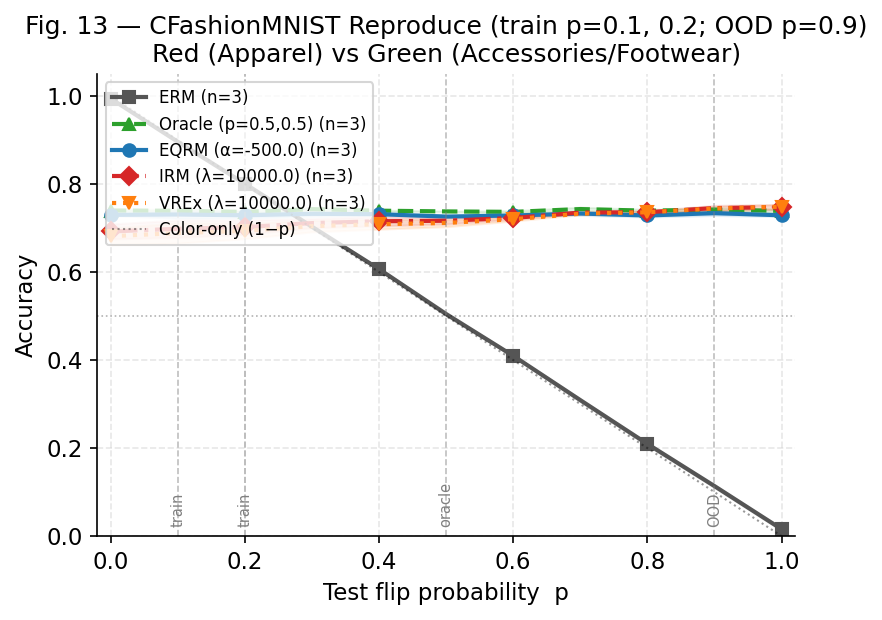


--- fig16_rmnist_reproduce.png ---


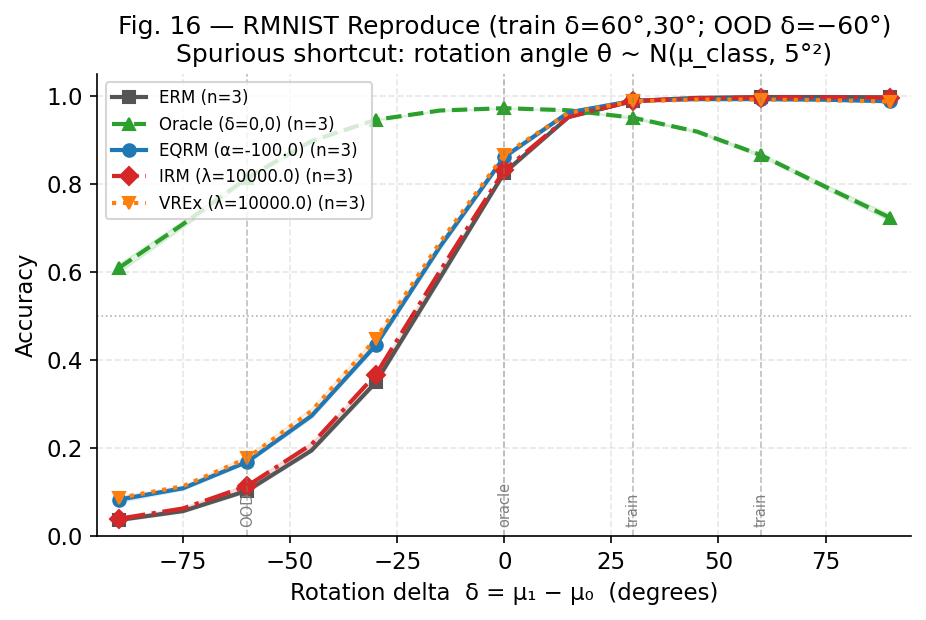


--- fig19_rmnist_grid.png ---


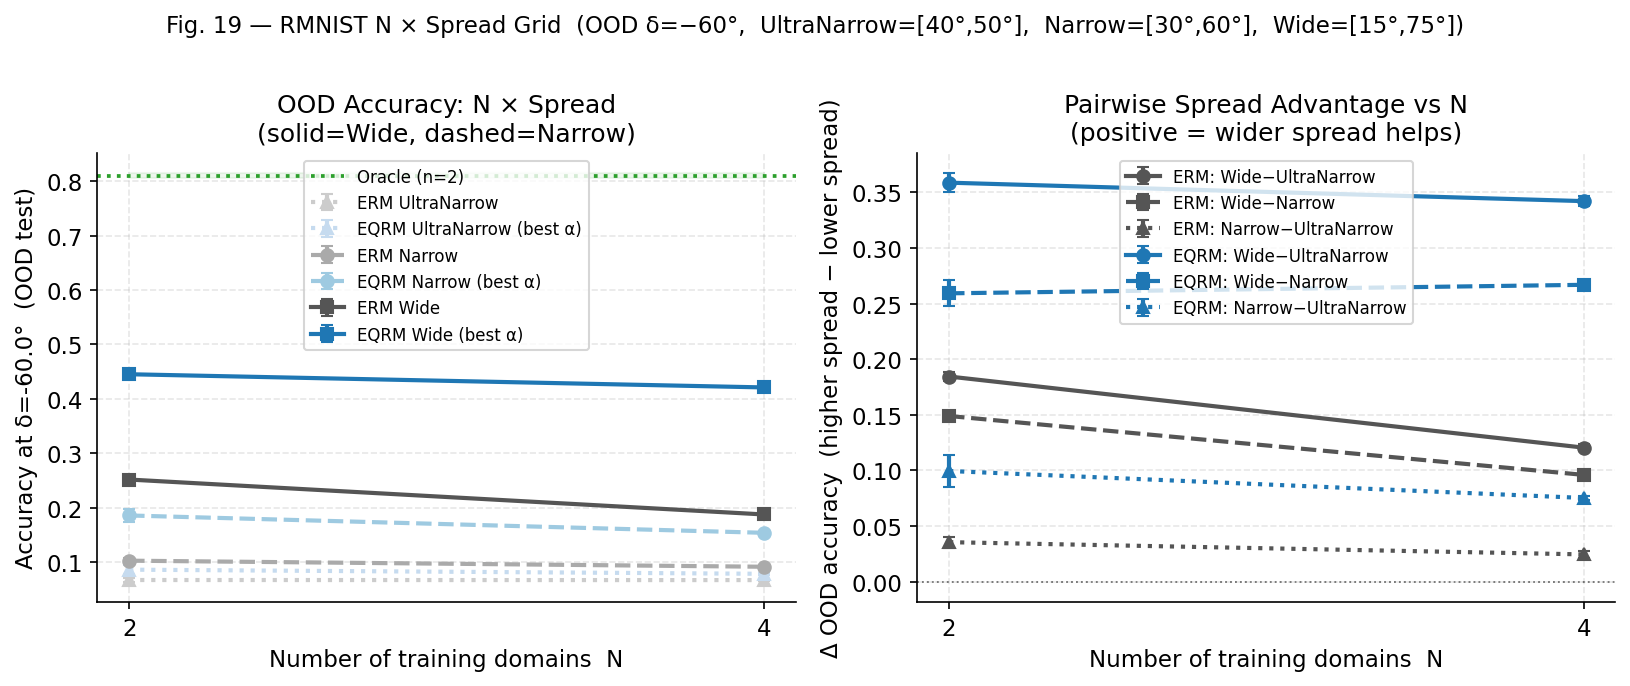


--- fig1_reproduce.png ---


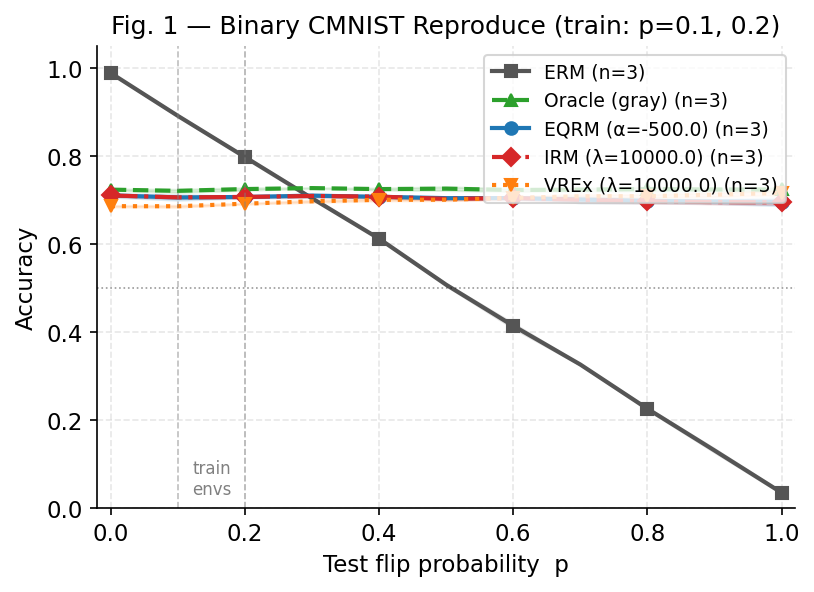


--- fig20_cross_dataset_ood.png ---


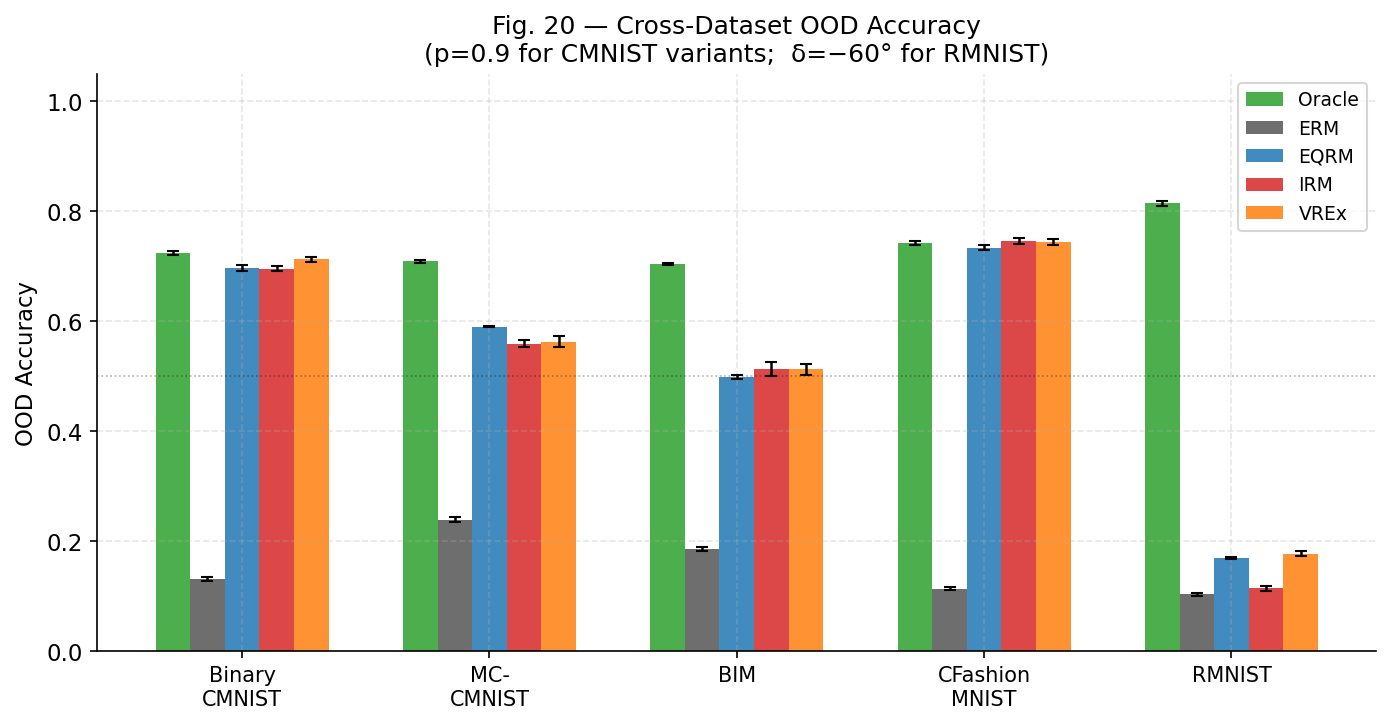


--- fig21_rmnist_grid_profiles.png ---


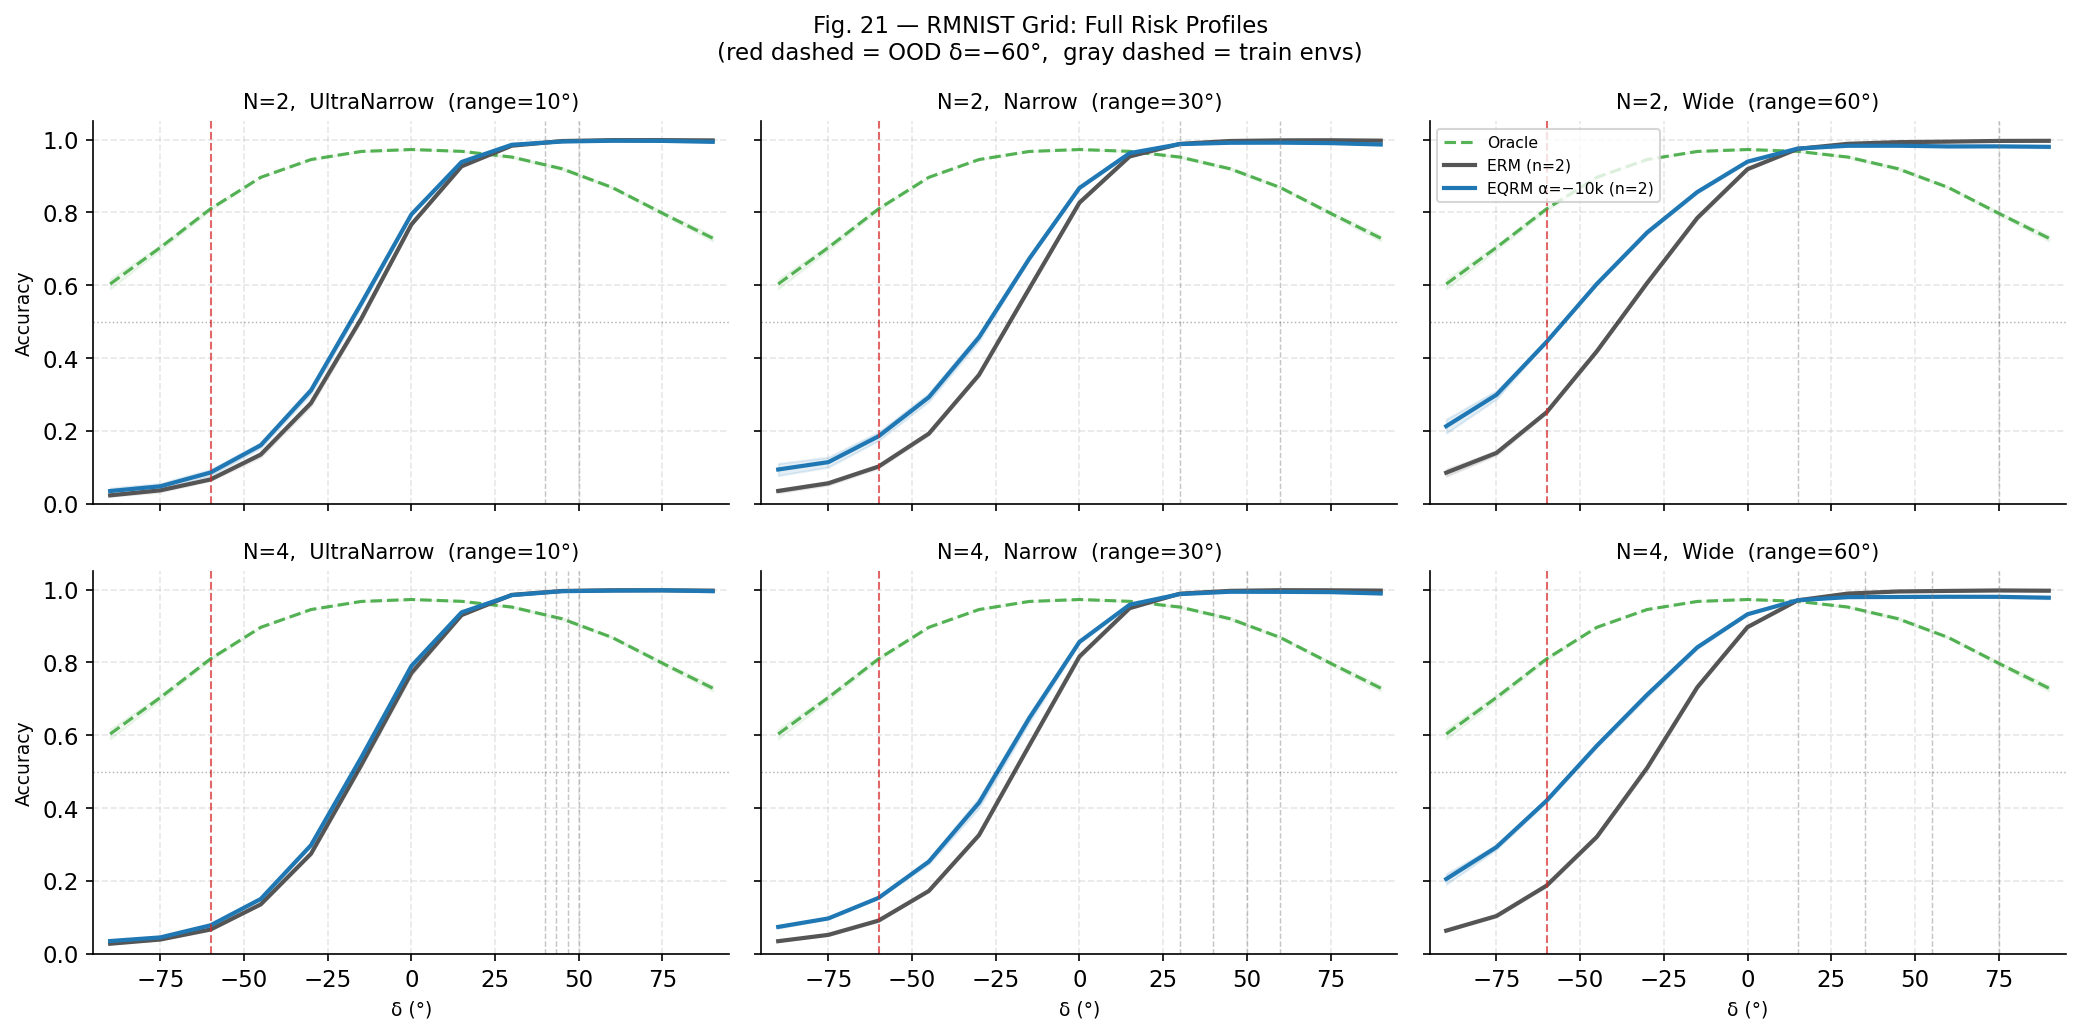


--- fig6_mc_reproduce.png ---


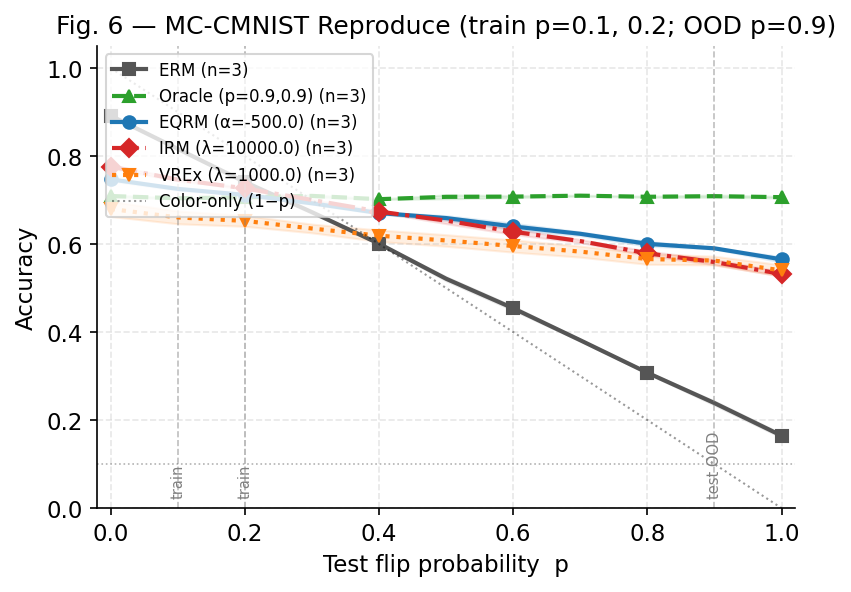


--- fig9_bim_reproduce.png ---


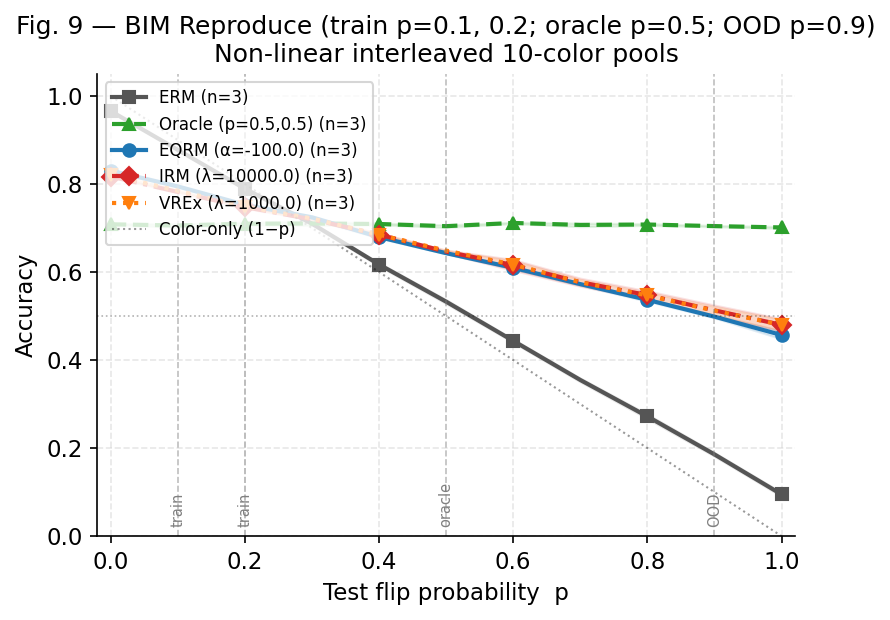


--- fig_burnin_ablation.png ---


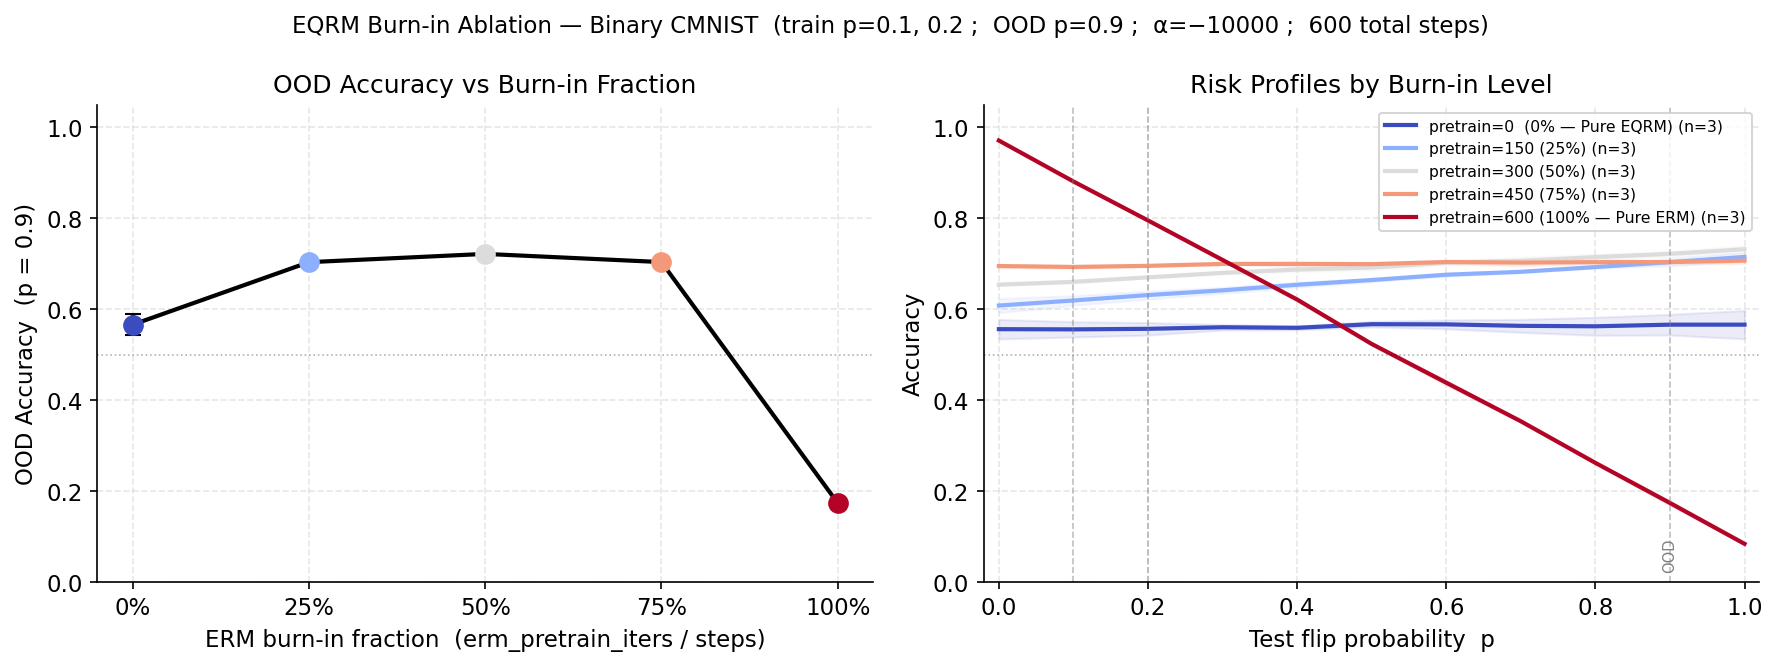


--- fig_spurious_ablation.png ---


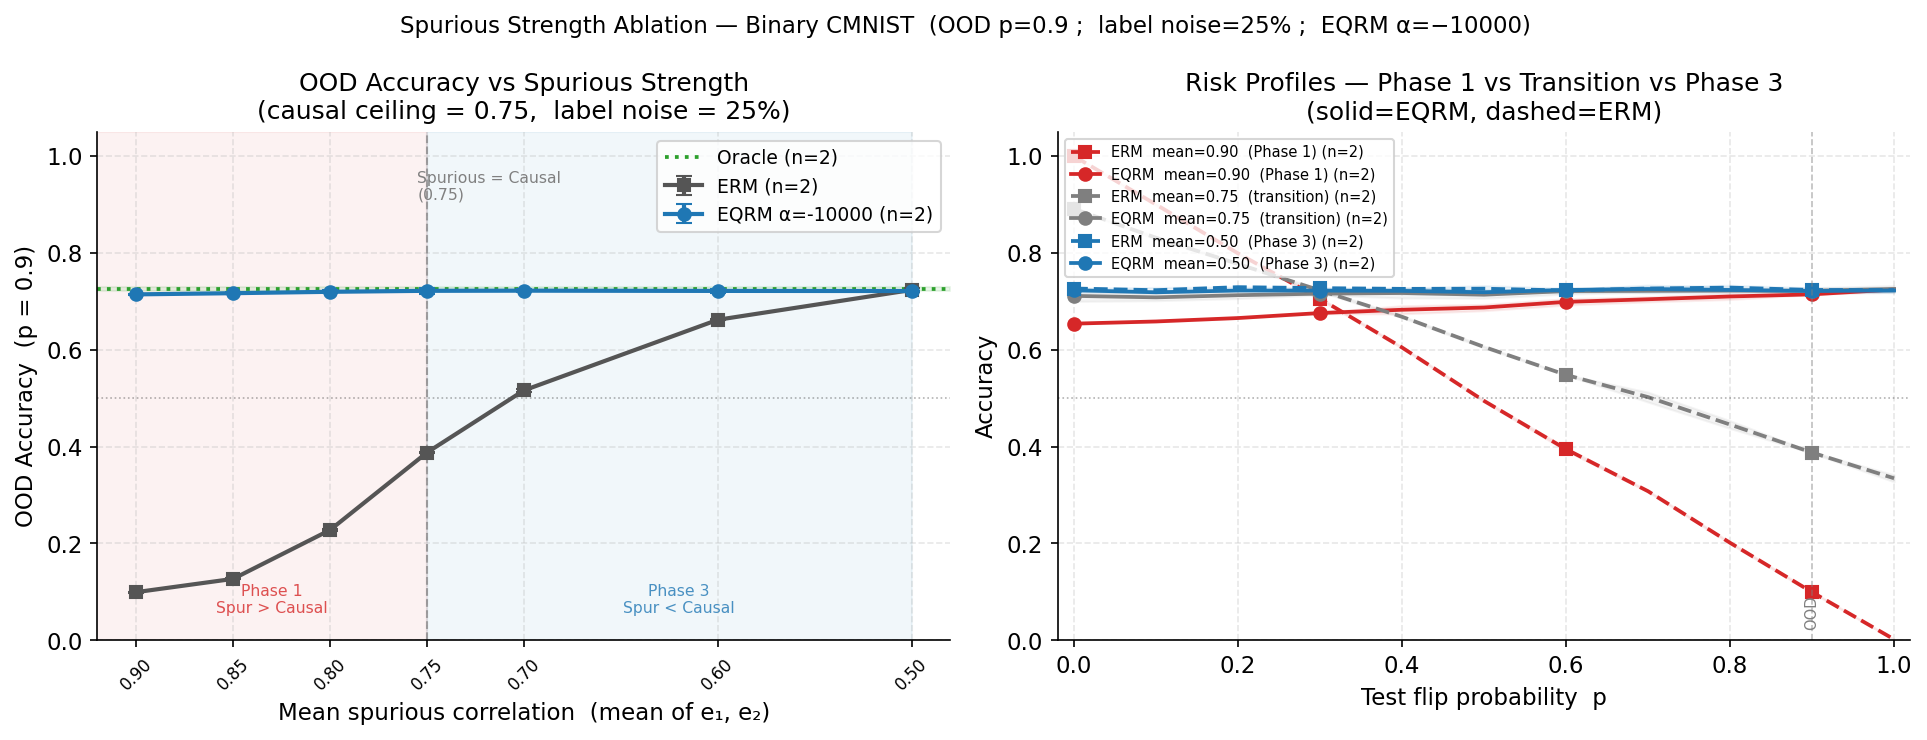

In [5]:
from IPython.display import Image, display
import glob as _glob

fig_paths = sorted(_glob.glob(os.path.join(FIGURES_DIR, '*.png')))
if not fig_paths:
    print("No figures found — run Cell 13 first.")
else:
    for p in fig_paths:
        name = os.path.basename(p)
        print(f"\n--- {name} ---")
        display(Image(p, width=800))
